### Configuração inicial

Importando bibliotecas necessárias

In [181]:
import matplotlib.pyplot as plt
from typing import List
import glob
import os
import numpy as np
import pandas as pd 
import seaborn as sns
import plotly.graph_objects as go
import numpy as np
import plotly.io as pio
import plotly.express as px

import warnings
warnings.filterwarnings('ignore')
warnings.simplefilter('ignore')

# Primeira Parte: Métricas Tradicionais
-- Acceptance, Latency, CPU, Cache, Banda, Tempo de Decisão

--Extra: Energia

## Função Para Coletar Dados

In [182]:
results_flows_directories = glob.glob('../../results/results_flows*/*') # Caso mude a estrutura dos diretórios, esse caminho deve ser alterado
results_flows_directories

['../../results\\results_flows\\ga_s_50_p_4_a_0.95_c_3',
 '../../results\\results_flows\\ga_s_50_p_4_a_0.97_c_3',
 '../../results\\results_flows\\ga_s_50_p_4_a_0.99_c_3',
 '../../results\\results_flows\\ga_s_50_p_4_a_1.0_c_0',
 '../../results\\results_flows\\g_s_50_p_4_a_0.95_c_3',
 '../../results\\results_flows\\g_s_50_p_4_a_0.97_c_3',
 '../../results\\results_flows\\g_s_50_p_4_a_0.99_c_3',
 '../../results\\results_flows\\g_s_50_p_4_a_1.0_c_0',
 '../../results\\results_flows\\msf_s_50_p_4_a_0.95_c_3',
 '../../results\\results_flows\\msf_s_50_p_4_a_0.97_c_3',
 '../../results\\results_flows\\msf_s_50_p_4_a_0.99_c_3',
 '../../results\\results_flows\\msf_s_50_p_4_a_1.0_c_0',
 '../../results\\results_flows\\musfico_s_50_p_4_a_0.95_c_3',
 '../../results\\results_flows\\musfico_s_50_p_4_a_0.97_c_3',
 '../../results\\results_flows\\musfico_s_50_p_4_a_0.99_c_3',
 '../../results\\results_flows\\musfico_s_50_p_4_a_1.0_c_0']

In [183]:
for alg_dir in results_flows_directories:
    simulacoes_okays = 0
    simu_exec_name = alg_dir.split('/')[-1].split('_')
    alg_name = simu_exec_name[1].split("\\")[1]
    number_of_fails = simu_exec_name[-1]
    ava = simu_exec_name[-3]
    print(alg_name,number_of_fails,ava)

ga 3 0.95
ga 3 0.97
ga 3 0.99
ga 0 1.0
g 3 0.95
g 3 0.97
g 3 0.99
g 0 1.0
msf 3 0.95
msf 3 0.97
msf 3 0.99
msf 0 1.0
musfico 3 0.95
musfico 3 0.97
musfico 3 0.99
musfico 0 1.0


In [184]:
aggregated_simulation_data = pd.DataFrame() 
algos = {}
def collect_data_from_alg_directory(results_flows_directories, metricas_coleta):
    data_nla = []
    log_simu = {}  # Essa variável serve apenas para verificar as simulações
    
    for alg_dir in results_flows_directories:
        simulacoes_okays = 0
        simu_exec_name = alg_dir.split('/')[-1].split('_')
        alg_name = simu_exec_name[1].split("\\")[1]
        number_of_fails = simu_exec_name[-1]
        ava = simu_exec_name[-3]


        if alg_name == 'g':
            alg_name = 'Greedy'
            alg_name = 'OSCIM/Greedy'
        if alg_name == 'ga':
            alg_name =  'GA'
        if alg_name == 'msf':
            alg_name = 'MSF'
        if alg_name == 'goku':
            alg_name = 'OSCIM'
        if alg_name == 'vegeta':
            alg_name = 'Resilient-OSCIM'
        if alg_name == 'musfico':
            alg_name = 'MuSFiCO'
        if alg_name == 'old':
            alg_name = 'All Backup'
        files = os.listdir(alg_dir)
        #print(f"Simulação: {alg_name}, {reliability}") 
        #print("Quantidade de csv: ", len(files))
        
        if alg_name not in log_simu:
            log_simu[alg_name] = {'files': len(files), 'simulacoes_sucesso': 0, 'Nulos': 0}
        else:

            log_simu[alg_name]['files'] += len(files)

        for file in files:
            data_path = os.path.join(alg_dir, file)
            try:
                simulation_df = pd.read_csv(data_path)
                #print(simulation_df)
                sfc_id_values = simulation_df['sfc_id'].values
            except Exception as e:
                print(f"Erro ao ler o arquivo {file}: {e}")
                continue
            simulation_is_success = 'sfc_cache_p3_48' in simulation_df['sfc_id'].values
            #print(simulation_is_success)
            if simulation_is_success: 
                # Seleciona as métricas
                simulation_df = simulation_df[metricas_coleta]
    
                # Define o nome do algoritmo e incrementa a contagem de simulações
                simulation_df['algorithm'] = alg_name
                simulation_df['number_of_fails'] = number_of_fails
                simulation_df['availability'] = ava
                simulation_df['simulation'] = log_simu[alg_name]['simulacoes_sucesso']
                
                data_nla.append(simulation_df)

                # Incrementa a contagem de simulações de sucesso e soma os valores nulos
                log_simu[alg_name]['simulacoes_sucesso'] += 1
                log_simu[alg_name]['Nulos'] += sum(simulation_df.isnull().sum())

    if data_nla:
        data_nla_f = pd.concat(data_nla)
    else:
        data_nla_f = pd.DataFrame()
        
    print("\nResumo das Simulações:")
    for alg, info in log_simu.items():
        print(f"Algoritmo: {alg}")
        print(f"  Quantidade de arquivos: {info['files']}")
        print(f"  Simulações de sucesso: {info['simulacoes_sucesso']}")
        print(f"  Dados nulos: {info['Nulos']}")
        print()

    return data_nla_f

Resiliencia Coleta

In [239]:
aggregated_simulation_data = pd.DataFrame() 
algos = {}
def collect_data_from_alg_directory(results_flows_directories, metricas_coleta):
    data_nla = []
    log_simu = {}  # Essa variável serve apenas para verificar as simulações
    
    for alg_dir in results_flows_directories:
        simulacoes_okays = 0
        simu_exec_name = alg_dir.split('/')[-1].split('_')
        alg_name = simu_exec_name[1].split("\\")[1]
        number_of_fails = simu_exec_name[-1]
        ava = simu_exec_name[-3]


        if alg_name == 'g':
            alg_name = 'Greedy'
            alg_name = 'OSCIM/Greedy'
        if alg_name == 'ga':
            alg_name =  'GA'
        if alg_name == 'msf':
            alg_name = 'MSF'
        if alg_name == 'goku':
            alg_name = 'OSCIM'
        if alg_name == 'vegeta':
            alg_name = 'Resilient-OSCIM'
        if alg_name == 'musfico':
            alg_name = 'MuSFiCO'
        if alg_name == 'old':
            alg_name = 'All Backup'
        files = os.listdir(alg_dir)
        #print(f"Simulação: {alg_name}, {reliability}") 
        #print("Quantidade de csv: ", len(files))
        
        if alg_name not in log_simu:
            log_simu[alg_name] = {'files': len(files), 'simulacoes_sucesso': 0, 'Nulos': 0}
        else:

            log_simu[alg_name]['files'] += len(files)

        for file in files:
            data_path = os.path.join(alg_dir, file)
            try:
                simulation_df = pd.read_csv(data_path)
                #print(simulation_df)
                sfc_id_values = simulation_df['sfc_id'].values
            except Exception as e:
                print(f"Erro ao ler o arquivo {file}: {e}")
                continue
            simulation_is_success = 'sfc_cache_p3_48' in simulation_df['sfc_id'].values
            #print(simulation_is_success)
            if simulation_is_success: 
                # Seleciona as métricas
                simulation_df = simulation_df[metricas_coleta]
    
                # Define o nome do algoritmo e incrementa a contagem de simulações
                simulation_df['algorithm'] = alg_name
                simulation_df['number_of_fails'] = number_of_fails
                simulation_df['availability'] = ava
                simulation_df['simulation'] = log_simu[alg_name]['simulacoes_sucesso']
                
                data_nla.append(simulation_df)

                # Incrementa a contagem de simulações de sucesso e soma os valores nulos
                log_simu[alg_name]['simulacoes_sucesso'] += 1
                log_simu[alg_name]['Nulos'] += sum(simulation_df.isnull().sum())

    if data_nla:
        data_nla_f = pd.concat(data_nla)
    else:
        data_nla_f = pd.DataFrame()
        
    print("\nResumo das Simulações:")
    for alg, info in log_simu.items():
        print(f"Algoritmo: {alg}")
        print(f"  Quantidade de arquivos: {info['files']}")
        print(f"  Simulações de sucesso: {info['simulacoes_sucesso']}")
        print(f"  Dados nulos: {info['Nulos']}")
        print()

    return data_nla_f

In [240]:

metricas_coleta = ["time_seconds","success","latency","cpu_utilization","cache_utilization","bandwidth_utilization",
            "decision_time_ms","sfc_id","running_sfcs",'cpu_saved','shared_vnfs','cpu_resilient','cache_resilient',
]

concatenate_data = collect_data_from_alg_directory(results_flows_directories, metricas_coleta)
concatenate_data['success'] = concatenate_data['success'].map({True: 1, False: 0})


Resumo das Simulações:
Algoritmo: GA
  Quantidade de arquivos: 100
  Simulações de sucesso: 100
  Dados nulos: 794

Algoritmo: OSCIM/Greedy
  Quantidade de arquivos: 100
  Simulações de sucesso: 99
  Dados nulos: 20548

Algoritmo: MSF
  Quantidade de arquivos: 100
  Simulações de sucesso: 100
  Dados nulos: 5140

Algoritmo: MuSFiCO
  Quantidade de arquivos: 100
  Simulações de sucesso: 100
  Dados nulos: 6196



## Carregamento dos dados

In [255]:
concatenate_data = collect_data_from_alg_directory(results_flows_directories, metricas_coleta)
concatenate_data['success'] = concatenate_data['success'].map({True: 1, False: 0})


Resumo das Simulações:
Algoritmo: GA
  Quantidade de arquivos: 100
  Simulações de sucesso: 100
  Dados nulos: 794

Algoritmo: OSCIM/Greedy
  Quantidade de arquivos: 100
  Simulações de sucesso: 99
  Dados nulos: 20548

Algoritmo: MSF
  Quantidade de arquivos: 100
  Simulações de sucesso: 100
  Dados nulos: 5140

Algoritmo: MuSFiCO
  Quantidade de arquivos: 100
  Simulações de sucesso: 100
  Dados nulos: 6196



In [242]:
# concatenate_data['availability'] = concatenate_data['availability'].astype(float)

In [256]:
concatenate_data = concatenate_data[(concatenate_data['time_seconds'] >= 200) & (concatenate_data['time_seconds'] <= 350)]

In [257]:
print("ALGORITMOS: ")
algoritmos = list(concatenate_data.algorithm.unique())
print(algoritmos)

ALGORITMOS: 
['GA', 'OSCIM/Greedy', 'MSF', 'MuSFiCO']


### Resultados de Aceitação e Latência (Com falha)

In [258]:
import pandas as pd
import plotly.express as px

def plot_custom_boxplot(dataframe, x_col, y_col, title="Boxplot", 
                        x_label=None, y_label=None, color_col=None, 
                        y_range=None, legend_orientation="h", legend_y=1.1, 
                        legend_x=0.5, width=800, height=600):
    # Configurar rótulos personalizados
    labels = {x_col: x_label if x_label else x_col, y_col: y_label if y_label else y_col}
    
    # Criar o boxplot
    fig = px.box(dataframe, x=x_col, y=y_col, title=title, labels=labels, color=color_col)
    
    # Atualizar layout do gráfico
    fig.update_layout(
        yaxis=dict(range=y_range),  # Configura o limite do eixo Y (se fornecido)
        legend=dict(orientation=legend_orientation, y=legend_y, x=legend_x, xanchor="center"),
        title_x=0.5,  # Centralizar título
        width=width,  # Largura do gráfico
        height=height  # Altura do gráfico
    )

    return fig

In [259]:
concatenate_data

,time_seconds,success,latency,cpu_utilization,cache_utilization,bandwidth_utilization,decision_time_ms,sfc_id,running_sfcs,cpu_saved,shared_vnfs,cpu_resilient,cache_resilient,algorithm,number_of_fails,availability,simulation
92,216.0,1,4.0,0.4611,0.3300,0.1160,67.898,sfc_cache_p1_11,40,66.666667,31,0.4611,0.3300,GA,3,0.95,0
93,216.1,1,3.0,0.4611,0.3300,0.1160,69.478,sfc_unique_p1_11,40,66.666667,31,0.4611,0.3300,GA,3,0.95,0
94,216.4,1,3.0,0.3908,0.2475,0.1026,59.013,sfc_cache_p4_5,34,58.000000,25,0.3908,0.2475,GA,3,0.95,0
95,216.5,1,5.0,0.3908,0.2475,0.1026,71.058,sfc_unique_p4_5,34,58.000000,25,0.3908,0.2475,GA,3,0.95,0
96,216.7,1,3.0,0.4097,0.2475,0.1079,79.131,sfc_cache_p1_5,36,66.333333,29,0.4097,0.2475,GA,3,0.95,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
167,337.2,1,5.0,0.5533,0.2750,0.1619,18.451,sfc_unique_p2_19,52,142.000000,75,0.5533,0.2750,MuSFiCO,0,1.0,99
168,337.3,1,5.0,0.5722,0.2750,0.1686,20.227,sfc_cache_p3_19,54,150.333333,79,0.5722,0.2750,MuSFiCO,0,1.0,99
169,337.3,1,5.0,0.5722,0.2750,0.1686,19.292,sfc_unique_p3_19,54,150.333333,79,0.5722,0.2750,MuSFiCO,0,1.0,99
170,337.4,1,5.0,0.5911,0.2750,0.1753,19.785,sfc_cache_p4_19,56,158.666667,83,0.5911,0.2750,MuSFiCO,0,1.0,99


In [260]:
concatenate_data["algorithm"] = concatenate_data["algorithm"].replace({
    "GA": "GA",
    "MSF": "MSF",
    "MuSFiCO": "MuSFiCO",
    "OSCIM/Greedy": "Greedy"
})

In [261]:
acceptance = concatenate_data[['success','algorithm','number_of_fails','availability','simulation','time_seconds']]
acceptance.dropna(inplace=True)
#acceptance = acceptance[(acceptance['time_seconds'] >= 240) & (acceptance['time_seconds'] <= 340)]
acceptance = acceptance.groupby(['algorithm','availability','number_of_fails']).mean().reset_index()

In [262]:
acceptance['success'] = acceptance['success'] * 100

In [263]:
acceptance

,algorithm,availability,number_of_fails,success,simulation,time_seconds
0,GA,0.95,3,97.761515,12.132157,260.329703
1,GA,0.97,3,97.824268,36.810042,259.486987
2,GA,0.99,3,98.924731,61.718280,261.711914
3,GA,1.0,0,99.241192,86.995122,275.833171
4,Greedy,0.95,3,48.631905,12.088797,263.744605
5,Greedy,0.97,3,52.805281,37.103410,265.284048
6,Greedy,0.99,3,53.846154,62.054054,265.948545
7,Greedy,1.0,0,55.923567,86.487898,274.373185
8,MSF,0.95,3,82.980456,12.039495,261.306433
9,MSF,0.97,3,84.873950,37.279080,262.096550


In [264]:
selected_availabilities = ['1.0','0.99', '0.97', '0.95'] # Substitua pelos valores desejados
filtered_data = acceptance[acceptance['availability'].isin(selected_availabilities)]

In [265]:
filtered_data

,algorithm,availability,number_of_fails,success,simulation,time_seconds
0,GA,0.95,3,97.761515,12.132157,260.329703
1,GA,0.97,3,97.824268,36.810042,259.486987
2,GA,0.99,3,98.924731,61.718280,261.711914
3,GA,1.0,0,99.241192,86.995122,275.833171
4,Greedy,0.95,3,48.631905,12.088797,263.744605
5,Greedy,0.97,3,52.805281,37.103410,265.284048
6,Greedy,0.99,3,53.846154,62.054054,265.948545
7,Greedy,1.0,0,55.923567,86.487898,274.373185
8,MSF,0.95,3,82.980456,12.039495,261.306433
9,MSF,0.97,3,84.873950,37.279080,262.096550


## Função de Plot

In [266]:
def create_grouped_bar_mplot(data, y_metric=None,y_title='', title='', ylim=None, width=9, height=6, font_size=28):
    """
    Cria um gráfico de barras agrupado com Matplotlib com opção de personalizar os limites do eixo Y, tamanho do gráfico e fontes.

    Parâmetros:
    - data (pd.DataFrame): Dados de entrada com colunas 'availability', 'success' e 'algorithm'.
    - y_metric (str): Nome da métrica para o eixo Y.
    - title (str): Título do gráfico.
    - ylim (list, optional): Lista com dois valores [y_min, y_max] para definir os limites do eixo Y. Default é None.
    - width (float, optional): Largura do gráfico. Default é 10.
    - height (float, optional): Altura do gráfico. Default é 6.
    - font_size (int, optional): Tamanho da fonte para o título, eixos e legendas. Default é 19.

    Retorna:
    - fig, ax: Objeto de figura e eixo do Matplotlib.
    """
    if y_metric is None:
        raise ValueError("A métrica para o eixo Y deve ser especificada usando o parâmetro 'y_metric'.")

    # Criar figura e eixos
    fig, ax = plt.subplots(figsize=(width, height))

    # Obter valores únicos de 'availability' e 'algorithm'
    availability_values = data['availability'].unique()
    algorithms = data['algorithm'].unique()

    # Definir posições para as barras
    x = np.arange(len(availability_values))
    bar_width = 0.8 / len(algorithms)  # Largura das barras (dividida pelo número de algoritmos)

    # Criar as barras para cada algoritmo
    hatches = ['/', '\\', '+', 'x', '+', 'x', 'o', 'O', '.', '*']  # Padrões de hachura
    colors = [f'#{hex(100 + i * 30)[2:]}{hex(100 + i * 30)[2:]}{hex(100 + i * 30)[2:]}' for i in range(len(algorithms))]  # Escala de cinza do claro ao escuro

    for i, algorithm in enumerate(algorithms):
        algorithm_data = data[data['algorithm'] == algorithm]
        ax.bar(
            x + i * bar_width,  # Ajustar posição das barras
            algorithm_data[y_metric],
            width=bar_width,
            label=algorithm,
            edgecolor='black',  # Borda preta
            color=colors[i % len(colors)],  # Escala de cinza
            hatch=hatches[i % len(hatches)],
            linewidth=1.6  # Padrão de hachura
        )

    # Adicionar grade horizontal
    ax.yaxis.grid(True, linestyle='--', linewidth=0.5, color='gray', alpha=0.7)

    # Configurar os ticks e rótulos do eixo X
    ax.set_xticks(x + bar_width * (len(algorithms) - 1) / 2)
    ax.set_xticklabels(availability_values, fontsize=font_size - 4)

    # Configurar rótulos dos eixos e título
    ax.set_xlabel('Availability', fontsize=font_size)
    ax.set_ylabel(y_title, fontsize=font_size)
    ax.set_title(title, fontsize=font_size + 4, pad = 30)

    # Configurar limites do eixo Y
    if ylim:
        ax.set_ylim(ylim)

    ax.tick_params(axis='y', labelsize=font_size-4)

    # Configurar a legenda
    ax.legend(fontsize=font_size - 15, title_fontsize=font_size - 6, loc='upper center', bbox_to_anchor=(0.48, 1.15), ncol=len(algorithms))

    # Ajustar layout
    plt.tight_layout()

    if y_metric:
        plt.savefig(f"{y_metric}.pdf", format="pdf",bbox_inches='tight')

    return fig, ax

# Exemplo de uso:
# df = pd.DataFrame({
#     'availability': ['Low', 'Medium', 'High', 'Low', 'Medium', 'High'],
#     'success': [20, 50, 80, 30, 60, 90],
#     'algorithm': ['Alg1', 'Alg1', 'Alg1', 'Alg2', 'Alg2', 'Alg2']
# })
# create_grouped_bar_plot(df, y_metric='success', title='Grouped Bar Plot Example', ylim=[0, 100])
# plt.show()


(<Figure size 900x600 with 1 Axes>,
 <Axes: xlabel='Availability', ylabel='Acceptance Ratio (%)'>)

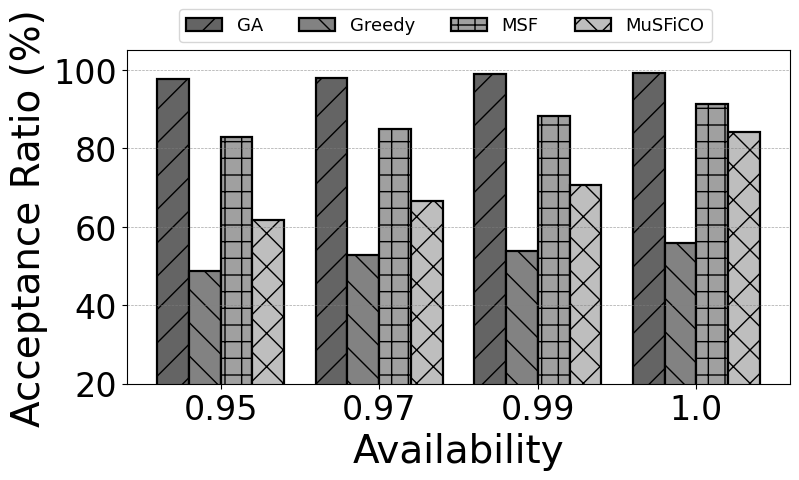

In [267]:
create_grouped_bar_mplot(filtered_data,y_metric='success',y_title='Acceptance Ratio (%)',title='', ylim=[20, 105])

In [268]:
latency = concatenate_data[['latency','algorithm','number_of_fails','availability','simulation','time_seconds']]
latency.dropna(inplace=True)
#latency = latency[(latency['time_seconds'] >= 240) & (latency['time_seconds'] <= 340)]
latency = latency.groupby(['algorithm','availability','number_of_fails']).mean().reset_index()

(<Figure size 900x600 with 1 Axes>,
 <Axes: xlabel='Availability', ylabel='Latency (ms)'>)

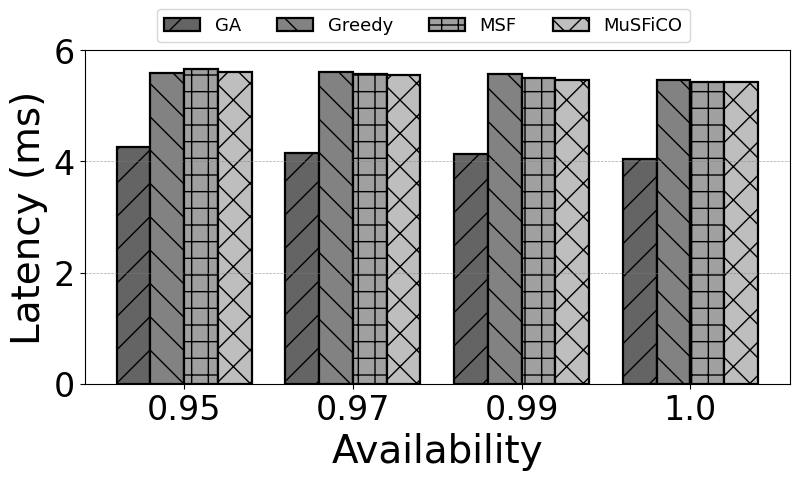

In [269]:
create_grouped_bar_mplot(latency,y_metric='latency',y_title='Latency (ms)',title='', ylim=[0, 6])

### Métricas de Consumo

In [270]:
consume_metrics = concatenate_data[['cpu_utilization', 'bandwidth_utilization','cache_utilization','cpu_saved','number_of_fails','availability',
                                         'shared_vnfs','simulation','decision_time_ms','algorithm','time_seconds','cpu_resilient','cache_resilient']]

In [271]:
#Tempo de Análise, descomente isso se você quiser definir isso
#filtered_data = consume_metrics[(consume_metrics['time_seconds'] >= 240) & (consume_metrics['time_seconds'] <= 400)]

In [272]:
df_consume_metrics = consume_metrics.groupby(['availability','algorithm','number_of_fails']).mean().reset_index()
df_consume_metrics['cpu_utilization'] = df_consume_metrics['cpu_utilization'] * 100
df_consume_metrics['bandwidth_utilization'] = df_consume_metrics['bandwidth_utilization'] * 100
df_consume_metrics['cache_utilization'] = df_consume_metrics['cache_utilization'] * 100
df_consume_metrics['cpu_resilient'] = df_consume_metrics['cpu_resilient'] * 100
df_consume_metrics['cache_resilient'] = df_consume_metrics['cache_resilient'] * 100

(<Figure size 900x600 with 1 Axes>,
 <Axes: xlabel='Availability', ylabel='CPU Utilization (%)'>)

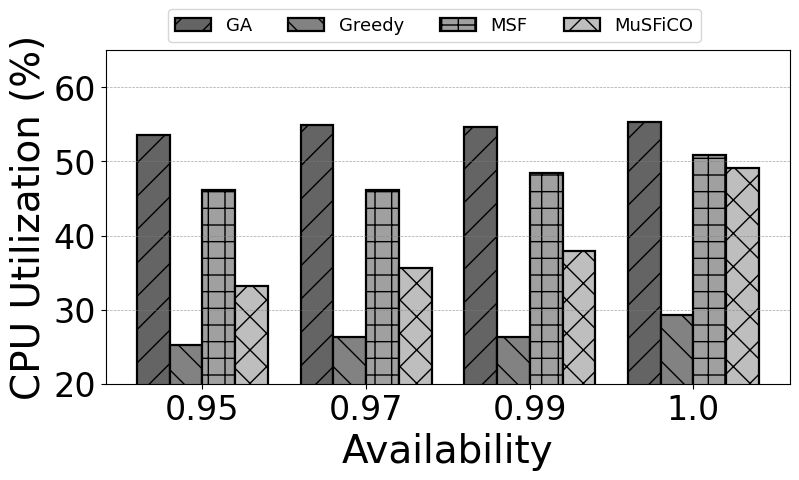

In [273]:
create_grouped_bar_mplot(df_consume_metrics,y_metric='cpu_utilization',y_title='CPU Utilization (%)', ylim=[20, 65])

(<Figure size 900x600 with 1 Axes>,
 <Axes: xlabel='Availability', ylabel='CPU Resilient (%)'>)

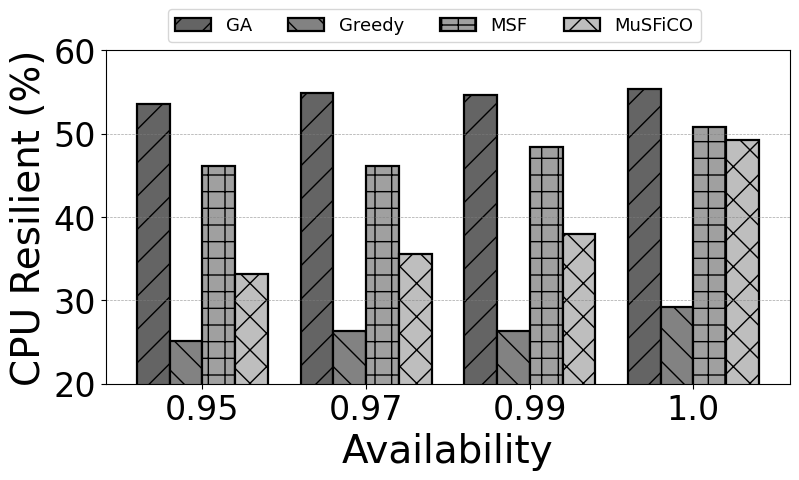

In [274]:
create_grouped_bar_mplot(df_consume_metrics,y_metric='cpu_resilient',y_title='CPU Resilient (%)', ylim=[20, 60])

(<Figure size 900x600 with 1 Axes>,
 <Axes: xlabel='Availability', ylabel='Cache Resilient (%)'>)

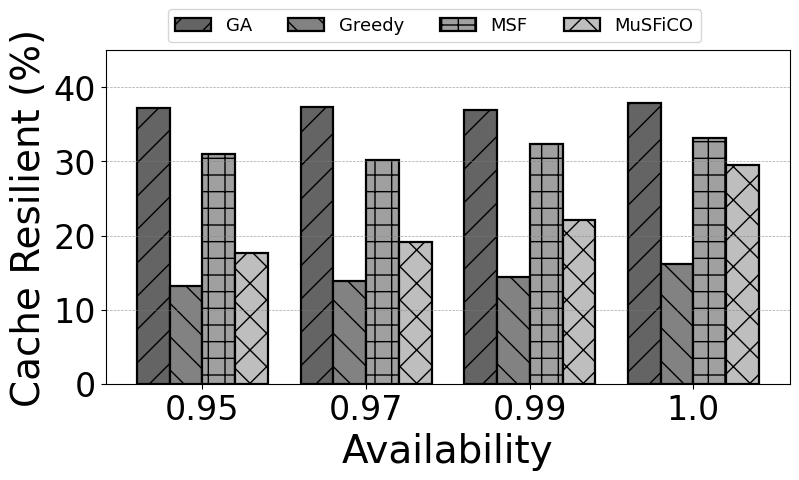

In [275]:
create_grouped_bar_mplot(df_consume_metrics,y_metric='cache_resilient',y_title='Cache Resilient (%)', ylim=[0, 45])

(<Figure size 900x600 with 1 Axes>,
 <Axes: xlabel='Availability', ylabel='Cache Utilization (%)'>)

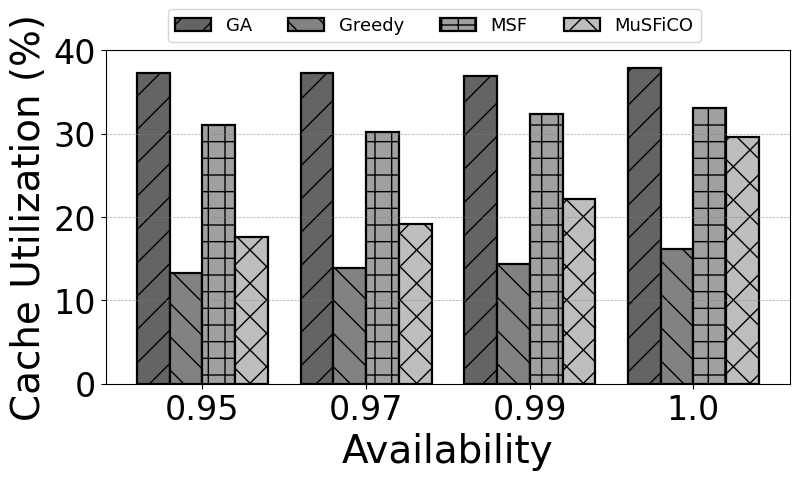

In [276]:
create_grouped_bar_mplot(df_consume_metrics,y_metric='cache_utilization',y_title='Cache Utilization (%)',title='', ylim=[0, 40])

(<Figure size 900x600 with 1 Axes>,
 <Axes: xlabel='Availability', ylabel='Bandwidth Utilization (%)'>)

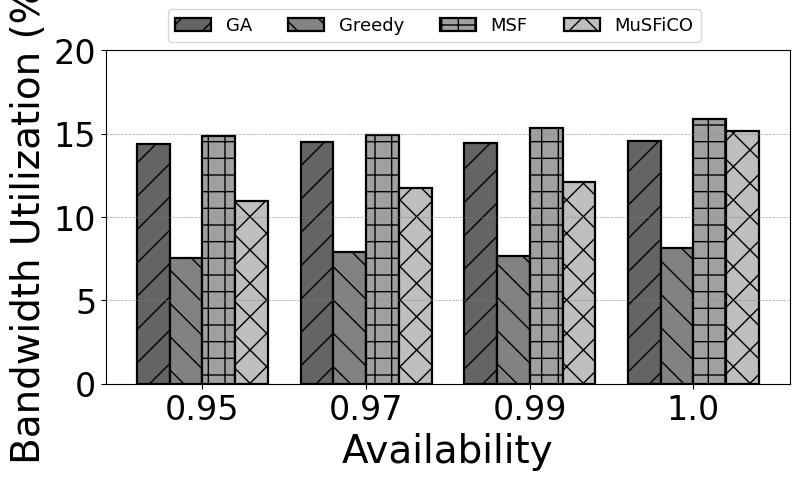

In [277]:
create_grouped_bar_mplot(df_consume_metrics,y_metric='bandwidth_utilization',y_title='Bandwidth Utilization (%)',title='', ylim=[0, 20])

(<Figure size 900x600 with 1 Axes>,
 <Axes: xlabel='Availability', ylabel='Decision Time (ms)'>)

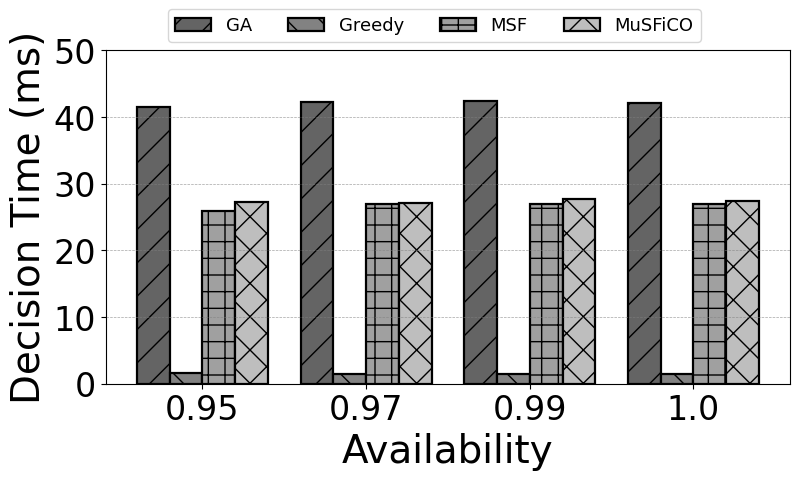

In [278]:
create_grouped_bar_mplot(df_consume_metrics,y_metric='decision_time_ms',y_title='Decision Time (ms)',title='', ylim=[0, 50])

### EXTRA: Energia

In [162]:
energy = df_consume_metrics[['cpu_utilization','algorithm','availability','number_of_fails']]
#energy = energy.groupby(['algorithm','simulation']).mean().reset_index()

In [163]:
#energy = energy.groupby(['algorithm','simulation']).mean().reset_index()

# Parâmetros do processador
power = 100  # em watts
ips = 96_100 * 1e6 
# Cálculo do EPI (em joules por instrução)
epi = (power / ips)
# Adicionando a coluna de EPI ajustada pela utilização
#energy["EPI"] = epi #* energy["cpu_utilization"]
energy["energy_consumption_KJ"] = epi * (energy["cpu_utilization"] * ips) * 100 / 1000 # Periodo de 100 segundos

(<Figure size 900x600 with 1 Axes>,
 <Axes: xlabel='Availability', ylabel='Energy Consumption (KJ)'>)

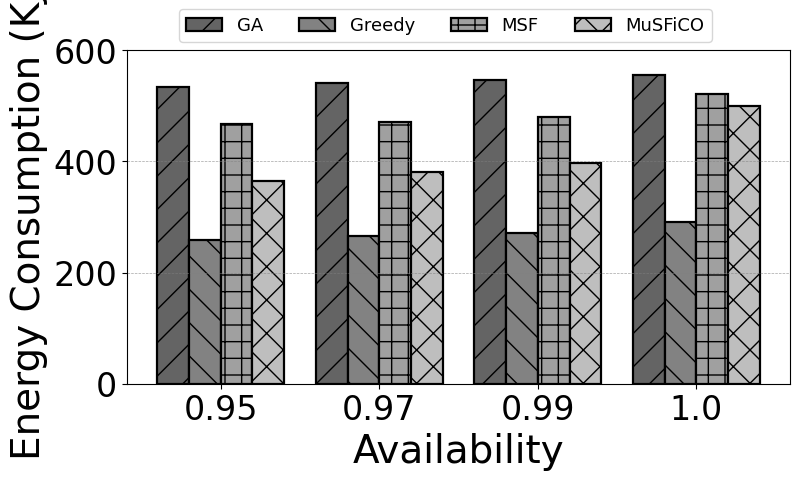

In [180]:
create_grouped_bar_mplot(energy,y_metric='energy_consumption_KJ',y_title='Energy Consumption (KJ)',title='', ylim=[0, 600])

# Segunda Parte:  Métricas de Resiliência

-- Taxa de Recover, diferença de latência e tempo de recuperação

In [165]:
results_res_directories = glob.glob('../../results/results_resilient*/*') # Caso mude a estrutura dos diretórios, esse caminho deve ser alterado
results_res_directories

['../../results\\results_resilient\\ga_s_50_p_4_a_0.95_c_3',
 '../../results\\results_resilient\\ga_s_50_p_4_a_0.97_c_3',
 '../../results\\results_resilient\\ga_s_50_p_4_a_0.99_c_3',
 '../../results\\results_resilient\\ga_s_50_p_4_a_1.0_c_0',
 '../../results\\results_resilient\\g_s_50_p_4_a_0.95_c_3',
 '../../results\\results_resilient\\g_s_50_p_4_a_0.97_c_3',
 '../../results\\results_resilient\\g_s_50_p_4_a_0.99_c_3',
 '../../results\\results_resilient\\g_s_50_p_4_a_1.0_c_0',
 '../../results\\results_resilient\\msf_s_50_p_4_a_0.95_c_3',
 '../../results\\results_resilient\\msf_s_50_p_4_a_0.97_c_3',
 '../../results\\results_resilient\\msf_s_50_p_4_a_0.99_c_3',
 '../../results\\results_resilient\\msf_s_50_p_4_a_1.0_c_0',
 '../../results\\results_resilient\\musfico_s_50_p_4_a_0.95_c_3',
 '../../results\\results_resilient\\musfico_s_50_p_4_a_0.97_c_3',
 '../../results\\results_resilient\\musfico_s_50_p_4_a_0.99_c_3',
 '../../results\\results_resilient\\musfico_s_50_p_4_a_1.0_c_0']

In [166]:
aggregated_simulation_data = pd.DataFrame() 
algos = {}
def res_collect_data_from_alg_directory(results_res_directories):
    data_nla = []
    log_simu = {}  # Essa variável serve apenas para verificar as simulações

    for alg_dir in results_res_directories:
        simulacoes_okays = 0
        simu_exec_name = alg_dir.split('/')[-1].split('_')
        alg_name = simu_exec_name[1].split("\\")[1]
        number_of_fails = simu_exec_name[-1]
        ava = simu_exec_name[-3]

        #alg_name = simu_exec_name[1].split("\\")[1]# simu_exec_name[3].split(f'\\')[1]
        # reliability = simu_exec_name[-1]
        if alg_name == 'g':
            alg_name = 'Greedy'
        if alg_name == 'ga':
            alg_name =  'GA'
        if alg_name == 'msf':
            alg_name = 'MSF'
        if alg_name == 'goku':
            alg_name = 'OSCIM'
        if alg_name == 'vegeta':
            alg_name = 'Resilient-OSCIM'
        if alg_name == 'musfico':
            alg_name = 'MuSFiCO'
        if alg_name == 'old':
            alg_name = 'All Backup'
        files = os.listdir(alg_dir)
        #print(f"Simulação: {alg_name}, {reliability}") 
        #print("Quantidade de csv: ", len(files))
        
        if alg_name not in log_simu:
            log_simu[alg_name] = {'files': len(files), 'simulacoes_sucesso': 0, 'Nulos': 0}
        else:
            log_simu[alg_name]['files'] += len(files)

        for file in files:
            data_path = os.path.join(alg_dir, file)
            try:
                simulation_df = pd.read_csv(data_path)
            except Exception as e:
                print(f"Erro ao ler o arquivo {file}: {e}")
                continue

            if not simulation_df.empty: 
                # Calculations
                mean_data_frame = pd.DataFrame()
                recover_success_rate = simulation_df["recover_success"].mean()
                backup_success_rate = simulation_df["backup_success"].mean()
                latency_diff_mean = simulation_df["latency_diff"].dropna().mean()
                time_to_recover_mean = simulation_df["time_to_recover"].dropna().mean()

                # Cálculo do percentual de melhoria da latência
                improvement_percentage = ((5 - latency_diff_mean) / 10) * 100

                mean_data_frame["recover_success"] = [recover_success_rate]
                mean_data_frame["backup_success"] = [backup_success_rate]
                mean_data_frame["latency_diff"] = [latency_diff_mean]
                mean_data_frame["latency_improvement"] = [improvement_percentage]
                mean_data_frame["time_to_recover"] = [time_to_recover_mean]

                # Seleciona as métricas relevantes
                mean_data_frame['algorithm'] = alg_name
                mean_data_frame['simulation'] = log_simu[alg_name]['simulacoes_sucesso']
                # print(mean_data_frame)
                data_nla.append(mean_data_frame)

                # Incrementa a contagem de simulações de sucesso e soma os valores nulos
                log_simu[alg_name]['simulacoes_sucesso'] += 1
                log_simu[alg_name]['Nulos'] += sum(mean_data_frame.isnull().sum())
    if data_nla:
        data_nla_f = pd.concat(data_nla)
    else:
        data_nla_f = pd.DataFrame()

    print("\nResumo das Simulações:")
    for alg, info in log_simu.items():
        print(f"Algoritmo: {alg}")
        print(f"  Quantidade de arquivos: {info['files']}")
        print(f"  Simulações de sucesso: {info['simulacoes_sucesso']}")
        print(f"  Dados nulos: {info['Nulos']}")
        print()

    return data_nla_f

In [167]:
res_aggregated_simulation_data = res_collect_data_from_alg_directory(results_res_directories)


Resumo das Simulações:
Algoritmo: GA
  Quantidade de arquivos: 100
  Simulações de sucesso: 75
  Dados nulos: 0

Algoritmo: Greedy
  Quantidade de arquivos: 100
  Simulações de sucesso: 75
  Dados nulos: 0

Algoritmo: MSF
  Quantidade de arquivos: 100
  Simulações de sucesso: 75
  Dados nulos: 0

Algoritmo: MuSFiCO
  Quantidade de arquivos: 100
  Simulações de sucesso: 75
  Dados nulos: 222



In [168]:
res_aggregated_simulation_data = res_aggregated_simulation_data.sort_values(by="algorithm")
res_aggregated_simulation_data

,recover_success,backup_success,latency_diff,latency_improvement,time_to_recover,algorithm,simulation
0,1.000000,0.0,0.064516,49.354839,18.093834,GA,0
0,1.000000,0.0,0.597222,44.027778,23.433910,GA,54
0,0.972973,0.0,0.208333,47.916667,23.152785,GA,53
0,0.972973,0.0,0.486111,45.138889,19.868333,GA,52
0,1.000000,0.0,-0.234375,52.343750,25.879051,GA,51
...,...,...,...,...,...,...,...
0,0.000000,0.0,NaN,NaN,NaN,MuSFiCO,21
0,0.000000,0.0,NaN,NaN,NaN,MuSFiCO,20
0,0.000000,0.0,NaN,NaN,NaN,MuSFiCO,19
0,0.000000,0.0,NaN,NaN,NaN,MuSFiCO,26


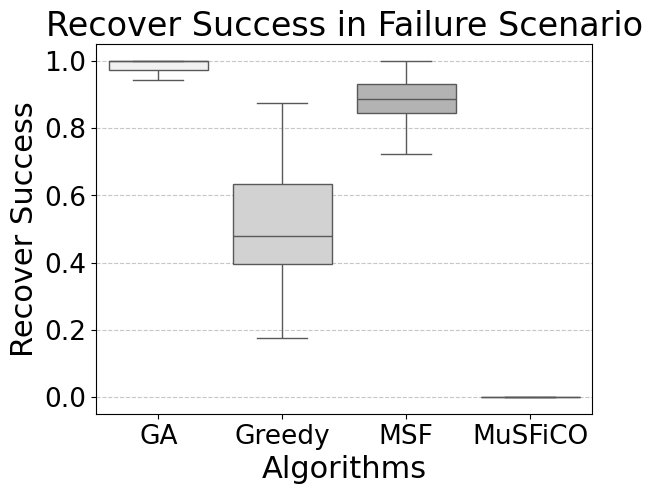

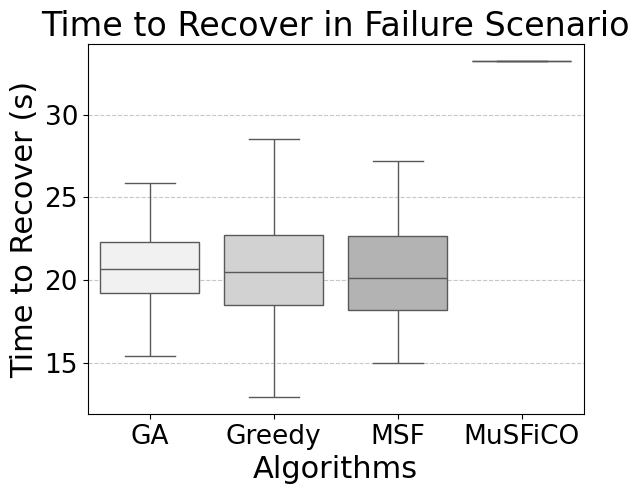

In [169]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import matplotlib as mpl

def plot_seaborn_boxplot(data, x_col, y_col, title, x_title, y_title, hatches, palette):
    data = data.dropna(subset=[x_col, y_col])

    #fig, axes = plt.subplots(figsize=(8, 6))
    fig, axes = plt.subplots()

    plt.rcParams.update({'font.size': 40})

    ax = sns.boxplot(data=data, x=x_col, y=y_col,ax=axes, palette=palette, showfliers=False)

    axes.set_title(title, fontsize=24)
    axes.set_xlabel(x_title, fontsize=22)
    axes.set_ylabel(y_title, fontsize=22)
    axes.grid(True, axis='y', linestyle='--', alpha=0.7)
    axes.tick_params(axis='y', labelsize=19)
    axes.tick_params(axis='x', labelsize=19)

    patches = [patch for patch in ax.patches if type(patch) == mpl.patches.PathPatch]
    # the number of patches should be evenly divisible by the number of hatches
    h = hatches * (len(patches) // len(hatches))
    # iterate through the patches for each subplot
    for patch, hatch in zip(patches, h):
        patch.set_hatch(hatch)
        fc = patch.get_facecolor()
        patch.set_edgecolor(fc)
        patch.set_facecolor('none') 
    
    plt.tight_layout
    plt.savefig(f"{y_col}_res.pdf", format="pdf")
    plt.show()

data = res_aggregated_simulation_data

hatches = ['//', '\\', '|', '-', '+', 'x', 'o', 'O', '.', '*']  # Padrões de hachura
light_gray_palette = sns.color_palette("light:#949494", n_colors=len(res_aggregated_simulation_data['algorithm'].unique()))

plot_seaborn_boxplot(
    data=data,
    x_col='algorithm',
    y_col='recover_success',
    title='Recover Success in Failure Scenario',
    x_title='Algorithms',
    y_title='Recover Success',
    hatches=hatches,
    palette=light_gray_palette
)

plot_seaborn_boxplot(
    data=data,
    x_col='algorithm',
    y_col='time_to_recover',
    title='Time to Recover in Failure Scenario',
    x_title='Algorithms',
    y_title='Time to Recover (s)',
    hatches=hatches,
    palette=light_gray_palette
)


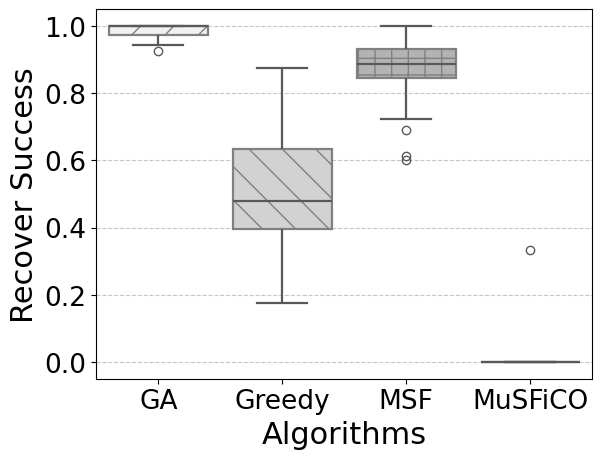

In [170]:
import matplotlib as mpl
import seaborn as sns

def plot_box(x_col, y_col, data, palette, hatches, x_title, y_title):
    ax = sns.boxplot(x=x_col, y=y_col, data=data,palette=palette, linewidth=1.6)

    ax.set_xlabel(x_title, fontsize=22)
    ax.set_ylabel(y_title, fontsize=22)
    ax.grid(True, axis='y', linestyle='--', alpha=0.7)
    ax.tick_params(axis='y', labelsize=19)
    ax.tick_params(axis='x', labelsize=19)

    # select the correct patches
    patches = [patch for patch in ax.patches if type(patch) == mpl.patches.PathPatch]
    # the number of patches should be evenly divisible by the number of hatches
    h = hatches * (len(patches) // len(hatches))
    # iterate through the patches for each subplot
    for patch, hatch in zip(patches, h):
        patch.set_hatch(hatch)
        #fc = patch.get_facecolor()
        patch.set_edgecolor('0.5')
        #patch.set_facecolor('none')

    plt.tight_layout

    fig = ax.get_figure()

    fig.savefig(f"{y_col}_res_2.pdf", format="pdf",bbox_inches='tight') 

hatches = ['/', '\\', '+', 'x']
light_gray_palette = sns.color_palette("light:#949494", n_colors=len(res_aggregated_simulation_data['algorithm'].unique()))

plot_box(x_col='algorithm',
         y_col='recover_success', 
         data = res_aggregated_simulation_data, 
         palette=light_gray_palette, 
         hatches=hatches,
         x_title='Algorithms', 
         y_title='Recover Success')


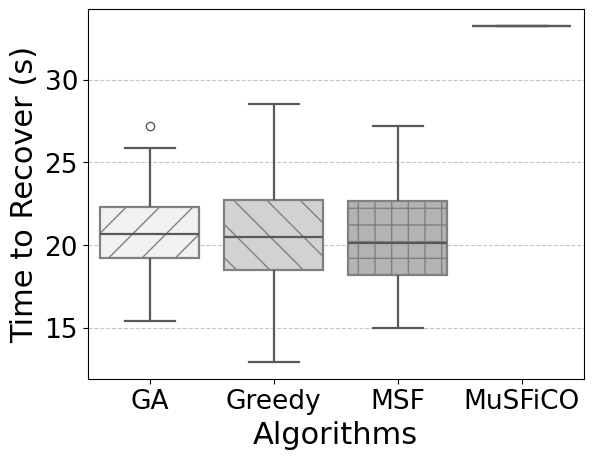

In [171]:
def plot_box2(x_col, y_col, data, palette, hatches, x_title, y_title):

    data = data.dropna(subset=[x_col, y_col])
    ax = sns.boxplot(x=x_col, y=y_col, data=data,palette=palette,linewidth=1.6)

    ax.set_xlabel(x_title, fontsize=22)
    ax.set_ylabel(y_title, fontsize=22)
    ax.grid(True, axis='y', linestyle='--', alpha=0.7)
    ax.tick_params(axis='y', labelsize=19)
    ax.tick_params(axis='x', labelsize=19)

    
    patches = [patch for patch in ax.patches if type(patch) == mpl.patches.PathPatch]
    h = hatches * (len(patches) // len(hatches))
    for patch, hatch in zip(patches, h):
        patch.set_hatch(hatch)
        patch.set_edgecolor('0.5')
    
    fig = ax.get_figure()

    fig.savefig(f"{y_col}_res_2.pdf", format="pdf",bbox_inches='tight') 

plot_box2(x_col='algorithm',
          y_col='time_to_recover', 
          data = res_aggregated_simulation_data, 
          palette=light_gray_palette, 
          hatches=hatches,
          x_title='Algorithms', 
          y_title='Time to Recover (s)'
          )

## Função de Plot Obs: mesma para todos

In [279]:
df = aggregated_simulation_data

# Lista de métricas
metrics = ["recover_success", "backup_success", "latency_diff","latency_improvement", "time_to_recover"]


# Criação de um gráfico para cada métrica
for metric in metrics:
    fig = go.Figure()
    for algo in df['algorithm'].unique():
        algo_data = df[df['algorithm'] == algo]
        fig.add_trace(go.Box(
            y=algo_data[metric],
            name=algo,
            boxmean=True,
            marker=dict(size=6),
            showlegend=True
        ))
    
    fig.update_layout(
        yaxis_title=metric,
        xaxis_title="Algorithm",
        boxmode='group',
        legend=dict(
            orientation="h",  # Legenda na horizontal
            yanchor="bottom",
            y=1.05,  # Coloca a legenda logo acima do gráfico
            xanchor="center",
            x=0.5,
            font=dict(size=14)  # Aumenta o tamanho da fonte da legenda
        ),
        autosize=True,  # Permite o ajuste automático do tamanho
        margin=dict(l=50, r=50, t=10, b=50),  # Ajustes nas margens para mais flexibilidade
        height=400,  # Ajuste flexível no tamanho do plot
        width=600,  # Ajuste flexível no tamanho do plot
        font=dict(
            size=16  # Aumenta o tamanho geral da fonte
        )
    )

    # Ajusta o tamanho da fonte dos eixos
    fig.update_xaxes(title_font=dict(size=18), tickfont=dict(size=14))
    fig.update_yaxes(title_font=dict(size=18), tickfont=dict(size=14))
    # Nome do arquivo baseado na métrica
    #file_name = f"{metric}.pdf"
    #fig.write_image(file_name, format="pdf")
    fig.show()


KeyError: 'algorithm'

# Terceira Parte: Gráficos Comparativos

Gráficos De Comparação

### Carregamento dos Dados

In [ ]:
aggregated_simulation_data = pd.DataFrame() 
algos = {}
def collect_data_from_alg_directory(results_flows_directories, metricas_coleta):
    data_nla = []
    log_simu = {}  # Essa variável serve apenas para verificar as simulações

    for alg_dir in results_flows_directories:
        simulacoes_okays = 0
        simu_exec_name = alg_dir.split('/')[-1].split('_')
        alg_name = simu_exec_name[1].split("\\")[1]
        number_of_fails = simu_exec_name[-1]
        ava = simu_exec_name[-3]
        if alg_name == 'g':
            alg_name = 'Greedy'
            alg_name = 'Greedy'
        if alg_name == 'ga':
            alg_name =  'GA'
        if alg_name == 'msf':
            alg_name = 'MSF'
        if alg_name == 'goku':
            alg_name = 'OSCIM'
        if alg_name == 'vegeta':
            alg_name = 'Resilient-OSCIM'
        if alg_name == 'musfico':
            alg_name = 'MuSFiCO'
        if alg_name == 'old':
            alg_name = 'All Backup'
        files = os.listdir(alg_dir)
        #print(f"Simulação: {alg_name}, {reliability}") 
        #print("Quantidade de csv: ", len(files))
        
        if alg_name not in log_simu:
            log_simu[alg_name] = {'files': len(files), 'simulacoes_sucesso': 0, 'Nulos': 0}
        else:

            log_simu[alg_name]['files'] += len(files)

        for file in files:
            data_path = os.path.join(alg_dir, file)
            try:
                simulation_df = pd.read_csv(data_path)
                #print(simulation_df)
                sfc_id_values = simulation_df['sfc_id'].values
            except Exception as e:
                print(f"Erro ao ler o arquivo {file}: {e}")
                continue
            simulation_is_success = 'sfc_cache_p3_48' in simulation_df['sfc_id'].values
            #print(simulation_is_success)
            if simulation_is_success: 
                # Seleciona as métricas
                simulation_df = simulation_df[metricas_coleta]
    
                # Define o nome do algoritmo e incrementa a contagem de simulações
                simulation_df['algorithm'] = alg_name
                simulation_df['number_of_fails'] = number_of_fails
                simulation_df['availability'] = ava
                simulation_df['simulation'] = log_simu[alg_name]['simulacoes_sucesso']
                
                data_nla.append(simulation_df)

                # Incrementa a contagem de simulações de sucesso e soma os valores nulos
                log_simu[alg_name]['simulacoes_sucesso'] += 1
                log_simu[alg_name]['Nulos'] += sum(simulation_df.isnull().sum())

    if data_nla:
        data_nla_f = pd.concat(data_nla)
    else:
        data_nla_f = pd.DataFrame()
        
    print("\nResumo das Simulações:")
    for alg, info in log_simu.items():
        print(f"Algoritmo: {alg}")
        print(f"  Quantidade de arquivos: {info['files']}")
        print(f"  Simulações de sucesso: {info['simulacoes_sucesso']}")
        print(f"  Dados nulos: {info['Nulos']}")
        print()

    return data_nla_f

metricas_coleta = ["time_seconds","success","latency","cpu_utilization","cache_utilization","bandwidth_utilization",
                   "decision_time_ms","sfc_id","running_sfcs",'cpu_saved','shared_vnfs']

concatenate_data = collect_data_from_alg_directory(results_flows_directories, metricas_coleta)
concatenate_data['success'] = concatenate_data['success'].map({True: 1, False: 0})
concatenate_data['success'] = concatenate_data['success'] * 100
concatenate_data['cpu_utilization'] = concatenate_data['cpu_utilization'] * 100
concatenate_data['cache_utilization'] = concatenate_data['cache_utilization'] * 100
concatenate_data['bandwidth_utilization'] = concatenate_data['bandwidth_utilization'] * 100

Erro ao ler o arquivo .ipynb_checkpoints: [Errno 21] Is a directory: '../../results/results_flows/ga_s_50_p_4_a_0.99_c_3/.ipynb_checkpoints'

Resumo das Simulações:
Algoritmo: Greedy
  Quantidade de arquivos: 40
  Simulações de sucesso: 39
  Dados nulos: 3485

Algoritmo: GA
  Quantidade de arquivos: 41
  Simulações de sucesso: 40
  Dados nulos: 1110

Algoritmo: MuSFiCO
  Quantidade de arquivos: 40
  Simulações de sucesso: 40
  Dados nulos: 2926

Algoritmo: MSF
  Quantidade de arquivos: 20
  Simulações de sucesso: 19
  Dados nulos: 1349



### Separação dos Dados

In [589]:
# Seleção do período de análise 
concatenate_data = concatenate_data[(concatenate_data['time_seconds'] >= 200) & (concatenate_data['time_seconds'] <= 900)]

In [590]:
# Separação dos dados com falha e sem falha
dados_com_falha = concatenate_data[(concatenate_data['availability']!='1.0')]
dados_sem_falha = concatenate_data[(concatenate_data['availability']=='1.0')]

In [591]:
def process_data(data, columns):
    processed = data[columns]
    processed.dropna(inplace=True)
    return processed.groupby(['algorithm', 'simulation']).mean().reset_index()

# Tratamento da Aceitação
acceptance_columns = ['success', 'algorithm', 'simulation', 'time_seconds']
acceptance_sem_falha = process_data(dados_sem_falha, acceptance_columns)
acceptance_com_falha = process_data(dados_com_falha, acceptance_columns)

# Tratamento da Latência
latency_columns = ['latency', 'algorithm', 'simulation', 'time_seconds']
latency_sem_falha = process_data(dados_sem_falha, latency_columns)
latency_com_falha = process_data(dados_com_falha, latency_columns)

In [592]:
dados_sem_falha = dados_sem_falha.drop(['time_seconds', 'sfc_id','availability','number_of_fails'], axis=1)
dados_com_falha = dados_com_falha.drop(['time_seconds', 'sfc_id','availability','number_of_fails'], axis=1)

dados_sem_falha = dados_sem_falha.groupby(['algorithm', 'simulation']).mean().reset_index()
dados_com_falha = dados_com_falha.groupby(['algorithm', 'simulation']).mean().reset_index()

In [593]:
dados_consumo_sem_falha = dados_sem_falha[['cpu_utilization', 'bandwidth_utilization','cache_utilization','cpu_saved',
                                         'shared_vnfs','simulation','decision_time_ms','algorithm']]

dados_consumo_com_falha = dados_com_falha[['cpu_utilization', 'bandwidth_utilization','cache_utilization','cpu_saved',
                                         'shared_vnfs','simulation','decision_time_ms','algorithm']]

In [594]:
# Inserção dos Dados de Energia 
# Parâmetros do processador
power = 100  # em watts
ips = 96_100 * 1e6 
# Cálculo do EPI (em joules por instrução)
epi = (power / ips)
# Adicionando a coluna de EPI ajustada pela utilização
#energy["EPI"] = epi #* energy["cpu_utilization"]

dados_consumo_sem_falha["energy_consumption_KJ"] = epi * (dados_consumo_sem_falha["cpu_utilization"] * ips) * 100 / 1000 # Periodo de 100 segundos
dados_consumo_com_falha["energy_consumption_KJ"] = epi * (dados_consumo_com_falha["cpu_utilization"] * ips) * 100 / 1000 # Periodo de 100 segundos

### Função de Plot lado a lado

In [942]:
import pandas as pd
import plotly.subplots as sp
import plotly.graph_objects as go

def plot_dual_boxplot(dataframe1, dataframe2, x_col, y_col, 
                      title1="Boxplot 1", title2="Boxplot 2",
                      x_label=None, y_label=None, color_col1=None, color_col2=None,
                      y_range=None, width=1200, height=600):
    # Configurar rótulos personalizados
    labels = {x_col: x_label if x_label else x_col, y_col: y_label if y_label else y_col}

    # Criar o primeiro boxplot
    fig1 = px.box(dataframe1, x=x_col, y=y_col, color=color_col1, labels=labels, title=title1)

    # Criar o segundo boxplot
    fig2 = px.box(dataframe2, x=x_col, y=y_col, color=color_col2, labels=labels, title=title2)

    # Criar subplots lado a lado
    fig = sp.make_subplots(rows=1, cols=2, subplot_titles=[title1, title2])

    # Adicionar trace do primeiro boxplot
    for trace in fig1.data:
        fig.add_trace(trace, row=1, col=1)

    # Adicionar trace do segundo boxplot
    for trace in fig2.data:
        fig.add_trace(trace, row=1, col=2)

    # Atualizar layout
    fig.update_layout(
        yaxis=dict(range=y_range),
        yaxis2=dict(range=y_range),  # Configura o limite do eixo Y para o segundo gráfico
        title_x=0.5,
        width=width,
        height=height
    )

    return fig

In [951]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

hatches = ['/', '\\', '|', '-', '+', 'x', 'o', 'O', '.', '*']  # Padrões de hachura

def mplot_dual_boxplot_deprecated(dataframe1, dataframe2, x_col, y_col, 
                      title1="Boxplot 1", title2="Boxplot 2",
                      x_label=None, y_label=None, color_col1=None, color_col2=None,
                      y_range=None, width=14, height=6, y_title = '', x_title = ''):
    """
    Plota dois boxplots lado a lado utilizando Seaborn com Matplotlib.

    Parameters:
        dataframe1 (pd.DataFrame): Primeiro DataFrame.
        dataframe2 (pd.DataFrame): Segundo DataFrame.
        x_col (str): Coluna do eixo X.
        y_col (str): Coluna do eixo Y.
        title1 (str): Título do primeiro gráfico.
        title2 (str): Título do segundo gráfico.
        x_label (str): Rótulo do eixo X.
        y_label (str): Rótulo do eixo Y.
        color_col1 (str): Coluna para cores no primeiro gráfico (não suportado no Seaborn).
        color_col2 (str): Coluna para cores no segundo gráfico (não suportado no Seaborn).
        y_range (tuple): Limites do eixo Y.
        width (float): Largura da figura.
        height (float): Altura da figura.
    """
    # Criar figura e eixos
    fig, axes = plt.subplots(1, 2, figsize=(width, height))

    # Configurar tamanho da fonte
    plt.rcParams.update({'font.size': 24})

    # Paleta de cinza clara
    light_gray_palette = sns.color_palette("light:#949494", n_colors=len(dataframe1[x_col].unique()))

    # Primeiro boxplot com hachuras
    ax1 = sns.boxplot(data=dataframe1, x=x_col, y=y_col, ax=axes[0], palette=light_gray_palette)
    patches = [patch for patch in ax1.patches if type(patch) == mpl.patches.PathPatch]
    h = hatches * (len(patches) // len(hatches))
    for patch, hatch in zip(patches, h):
        patch.set_hatch(hatch)
        patch.set_edgecolor('0.5')
    axes[0].set_title(title1)
    axes[0].set_xlabel(x_title, fontsize=24)
    axes[0].set_ylabel(y_title, fontsize=24)
    axes[0].grid(True, axis='y', linestyle='--', alpha=0.7)  # Adicionar grid horizontal

    # Segundo boxplot com hachuras
    ax2 = sns.boxplot(data=dataframe2, x=x_col, y=y_col, ax=axes[1], palette=light_gray_palette)
    patches = [patch for patch in ax2.patches if type(patch) == mpl.patches.PathPatch]
    h = hatches * (len(patches) // len(hatches))
    for patch, hatch in zip(patches, h):
        patch.set_hatch(hatch)
        patch.set_edgecolor('0.5')
    axes[1].set_title(title2)
    axes[1].set_xlabel(x_title, fontsize=24)
    axes[1].set_ylabel(None)
    axes[1].grid(True, axis='y', linestyle='--', alpha=0.7)  # Adicionar grid horizontal

    axes[0].tick_params(axis='y', labelsize=21)
    axes[1].tick_params(axis='y', labelsize=21)
    axes[0].tick_params(axis='x', labelsize=21)
    axes[1].tick_params(axis='x', labelsize=21)
    # Ajustar os limites do eixo Y, se fornecido
    if y_range:
        axes[0].set_ylim(y_range)
        axes[1].set_ylim(y_range)

    # Ajustar layout
    plt.tight_layout()

    if y_col:
        plt.savefig(f"{y_col}_comp.pdf", format="pdf", pad_inches=0)


    plt.show()

    

In [1231]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib as mpl  # Importação necessária para hachuras

hatches = ['/', '\\', '+', 'x', '+', 'x', 'o', 'O', '.', '*']  # Padrões de hachura

def mplot_dual_boxplot(dataframe1, dataframe2, x_col, y_col, 
                      title1="Boxplot 1", title2="Boxplot 2",
                      x_title=None, y_title=None,
                      y_range=None, width=14, height=6):
    """
    Plota dois boxplots lado a lado utilizando Seaborn com Matplotlib.

    Parameters:
        dataframe1 (pd.DataFrame): Primeiro DataFrame.
        dataframe2 (pd.DataFrame): Segundo DataFrame.
        x_col (str): Coluna do eixo X.
        y_col (str): Coluna do eixo Y.
        title1 (str): Título do primeiro gráfico.
        title2 (str): Título do segundo gráfico.
        x_title (str): Rótulo do eixo X.
        y_title (str): Rótulo do eixo Y.
        y_range (tuple): Limites do eixo Y.
        width (float): Largura da figura.
        height (float): Altura da figura.
    """
    # Criar figura e eixos
    fig, axes = plt.subplots(1, 2, figsize=(width, height))

    # Configurar tamanho da fonte
    plt.rcParams.update({'font.size': 24})

    # Paleta de cinza clara
    light_gray_palette = sns.color_palette("light:#949494", n_colors=len(dataframe1[x_col].unique()))

    # Primeiro boxplot com hachuras
    ax1 = sns.boxplot(data=dataframe1, x=x_col, y=y_col, ax=axes[0], palette=light_gray_palette, linewidth=2)
    patches = [patch for patch in ax1.patches if isinstance(patch, mpl.patches.PathPatch)]
    h = hatches * (len(patches) // len(hatches) + 1)  # Ajusta para cobrir todos os patches
    for patch, hatch in zip(patches, h):
        patch.set_hatch(hatch)
        patch.set_edgecolor('0.5')
    axes[0].set_title(title1,fontsize=24)
    axes[0].set_xlabel(x_title if x_title else x_col, fontsize=24)
    axes[0].set_ylabel(y_title if y_title else y_col, fontsize=24)
    axes[0].grid(True, axis='y', linestyle='--', alpha=0.7)  # Adicionar grid horizontal

    # Segundo boxplot com hachuras
    ax2 = sns.boxplot(data=dataframe2, x=x_col, y=y_col, ax=axes[1], palette=light_gray_palette, linewidth=2)
    patches = [patch for patch in ax2.patches if isinstance(patch, mpl.patches.PathPatch)]
    for patch, hatch in zip(patches, h):
        patch.set_hatch(hatch)
        patch.set_edgecolor('0.5')
    axes[1].set_title(title2, fontsize=24)
    axes[1].set_xlabel(x_title if x_title else x_col, fontsize=24)
    axes[1].set_ylabel(None)
    axes[1].grid(True, axis='y', linestyle='--', alpha=0.7)  # Adicionar grid horizontal

    axes[0].tick_params(axis='y', labelsize=21)
    axes[1].tick_params(axis='y', labelsize=21)
    axes[0].tick_params(axis='x', labelsize=21)
    axes[1].tick_params(axis='x', labelsize=21)

    # Ajustar os limites do eixo Y, se fornecido
    if y_range:
        axes[0].set_ylim(y_range)
        axes[1].set_ylim(y_range)

    # Ajustar layout
    plt.tight_layout()

    # Salvar gráfico como PDF se y_col for fornecido
    if y_col:
        plt.savefig(f"{y_col}_comp.pdf", format="pdf", bbox_inches='tight')

    plt.show()


In [ ]:
mplot_dual_boxplot_deprecated(dataframe1=acceptance_com_falha,
                        dataframe2=acceptance_sem_falha,
                        x_col="algorithm",y_col="success",
                        title1="with Failure ",title2="without Failure",
                        color_col1="algorithm",color_col2="algorithm",
                        y_range=(60, 100),y_title='Acceptance Ratio (%)', x_title='Algorithm')

NameError: name 'mplot_dual_boxplot_deprecated' is not defined

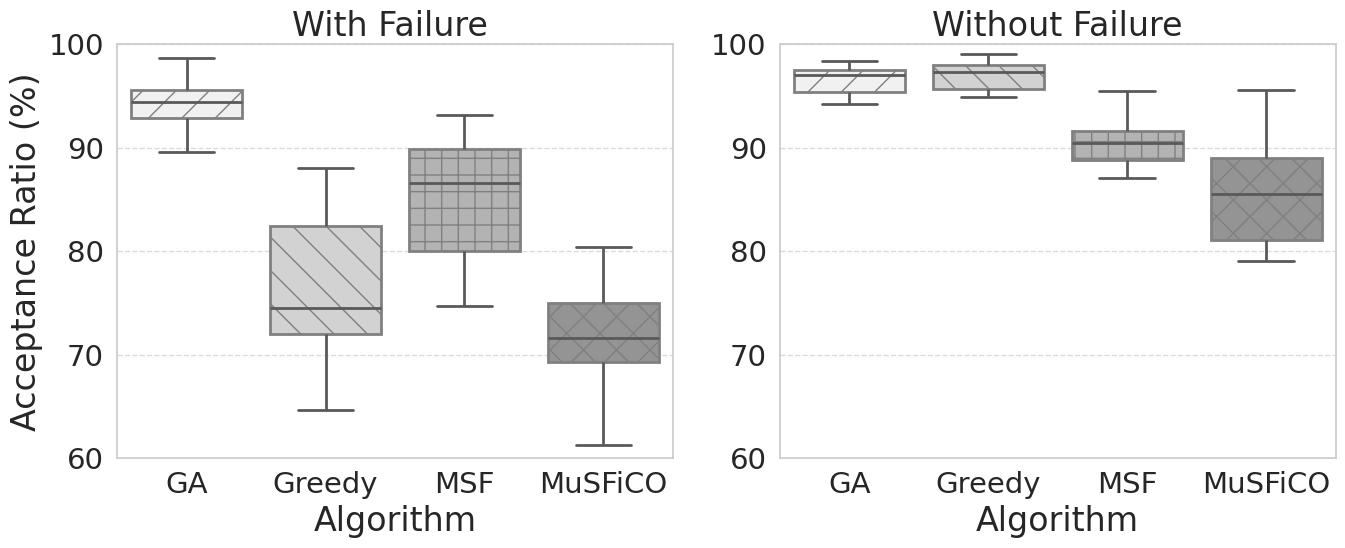

In [1232]:
mplot_dual_boxplot(dataframe1=acceptance_com_falha,
                        dataframe2=acceptance_sem_falha,
                        x_col="algorithm",y_col="success",
                        title1="With Failure ",title2="Without Failure",
                        y_range=(60, 100),y_title='Acceptance Ratio (%)', x_title='Algorithm')

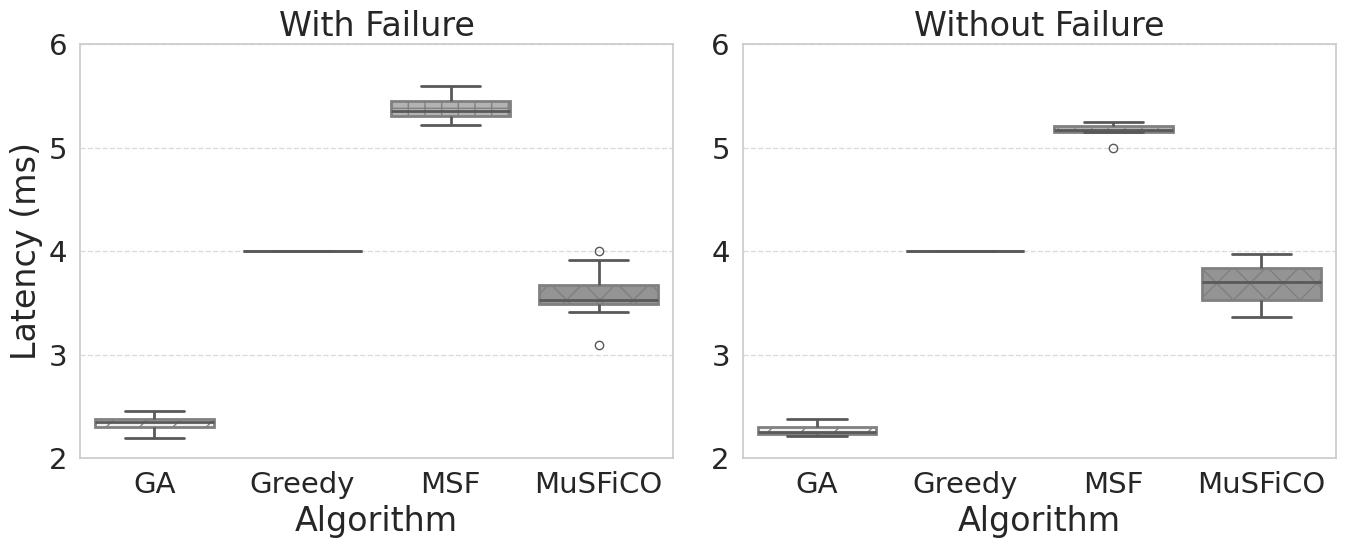

In [1233]:
mplot_dual_boxplot(dataframe1=latency_com_falha,
                        dataframe2=latency_sem_falha,
                        x_col="algorithm",y_col="latency",
                        title1="With Failure",title2="Without Failure",
                        y_range=(2, 6),y_title='Latency (ms)', x_title='Algorithm')

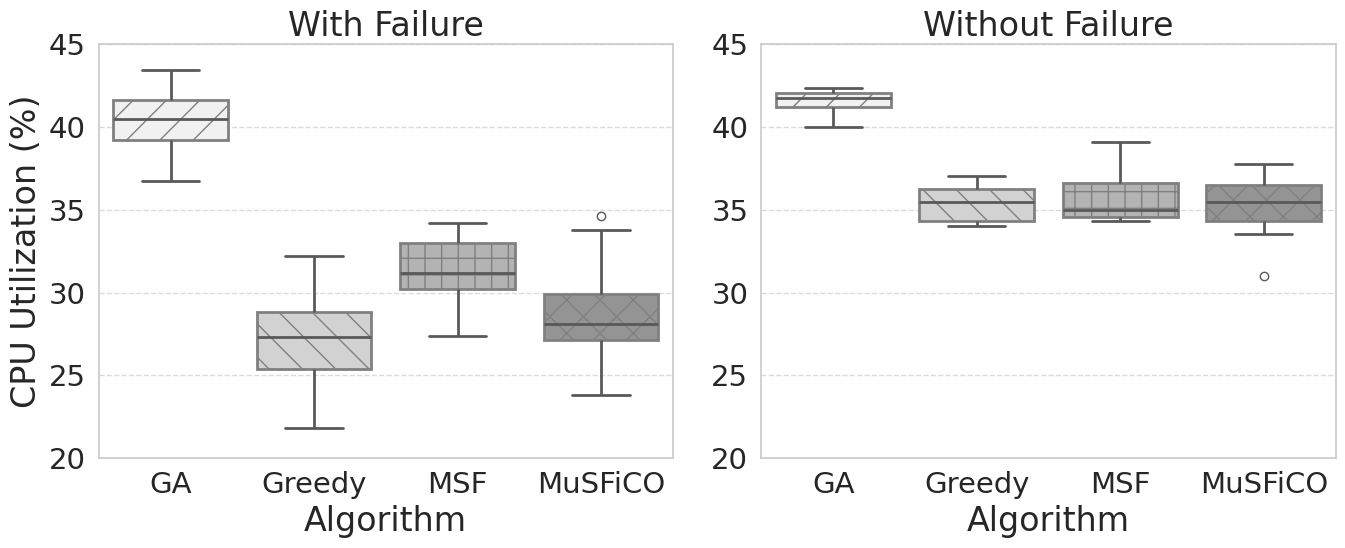

In [1234]:
# Gerar o gráfico
mplot_dual_boxplot(dataframe1=dados_consumo_com_falha,
                        dataframe2=dados_consumo_sem_falha,
                        x_col="algorithm",y_col="cpu_utilization",
                        title1="With Failure",title2="Without Failure",
                        y_range=(20, 45), y_title='CPU Utilization (%)', x_title='Algorithm')

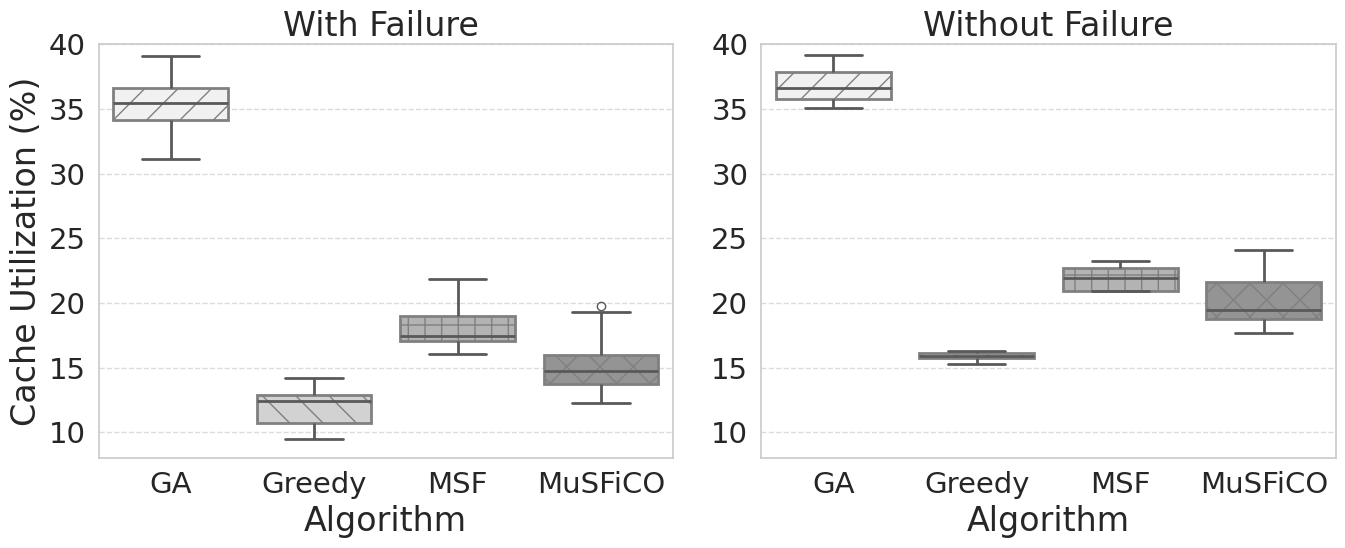

In [1235]:
mplot_dual_boxplot(dataframe1=dados_consumo_com_falha,
                        dataframe2=dados_consumo_sem_falha,
                        x_col="algorithm",y_col="cache_utilization",
                        title1="With Failure ",title2="Without Failure",
                        y_range=(8, 40), y_title='Cache Utilization (%)',x_title= 'Algorithm')

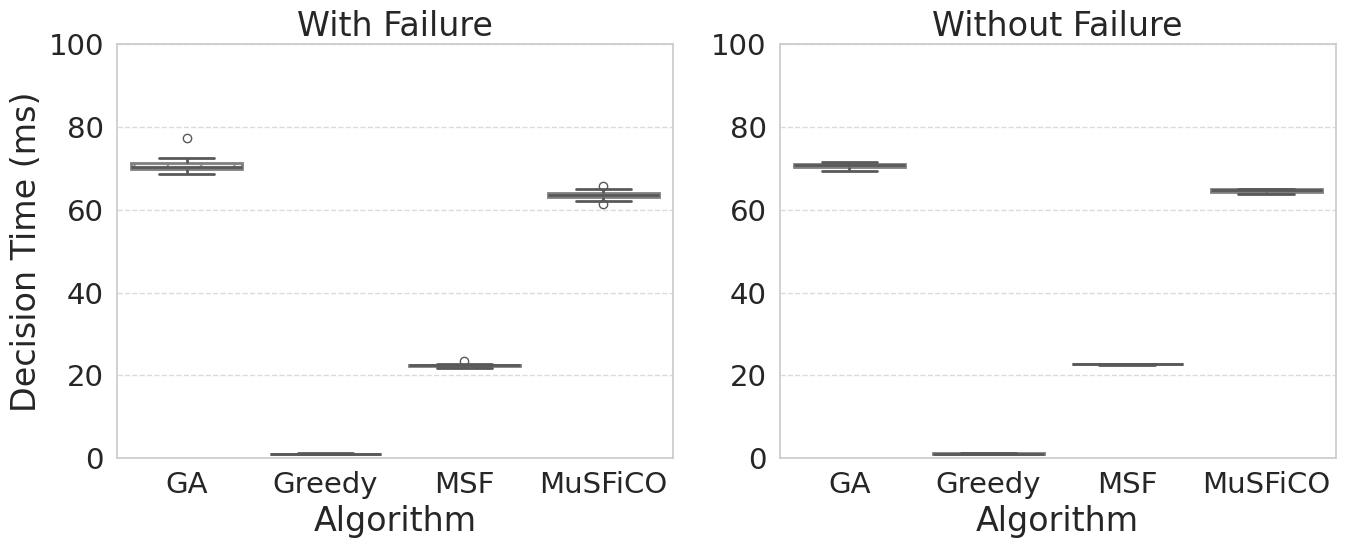

In [1236]:
mplot_dual_boxplot(dataframe1=dados_consumo_com_falha,
                        dataframe2=dados_consumo_sem_falha,
                        x_col="algorithm",y_col="decision_time_ms",
                        title1="With Failure",title2="Without Failure",
                        y_range=(0, 100),y_title='Decision Time (ms)',x_title='Algorithm')

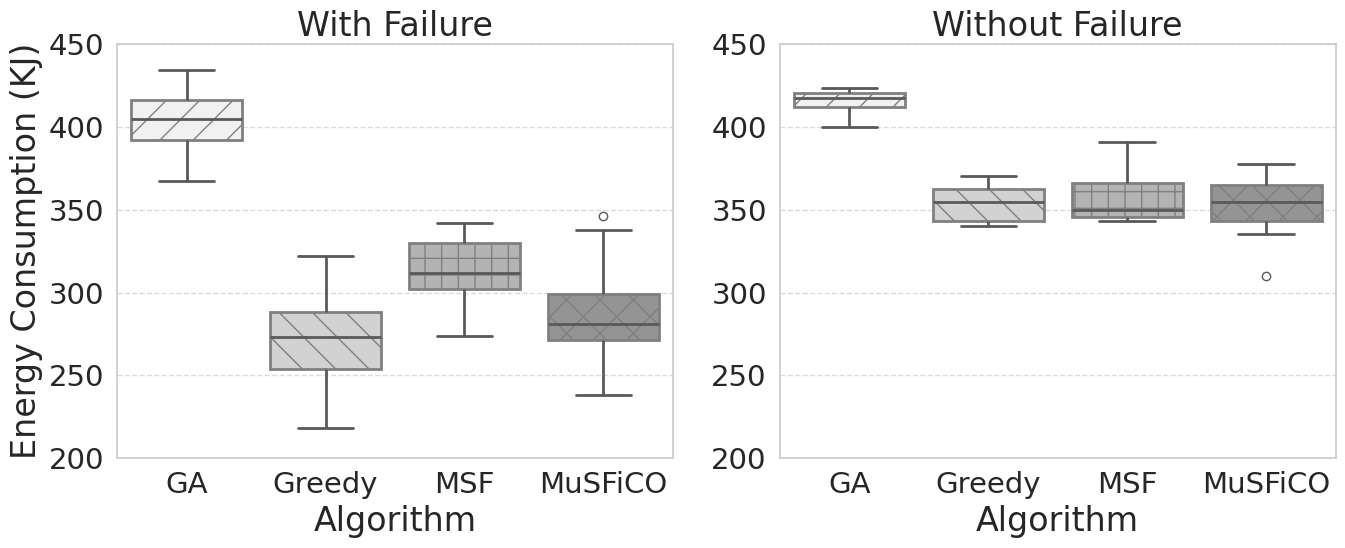

In [1237]:
mplot_dual_boxplot(dataframe1=dados_consumo_com_falha,
                        dataframe2=dados_consumo_sem_falha,
                        x_col="algorithm",y_col="energy_consumption_KJ",
                        title1="With Failure",title2="Without Failure",
                        y_range=(200, 450),y_title='Energy Consumption (KJ)',x_title='Algorithm')

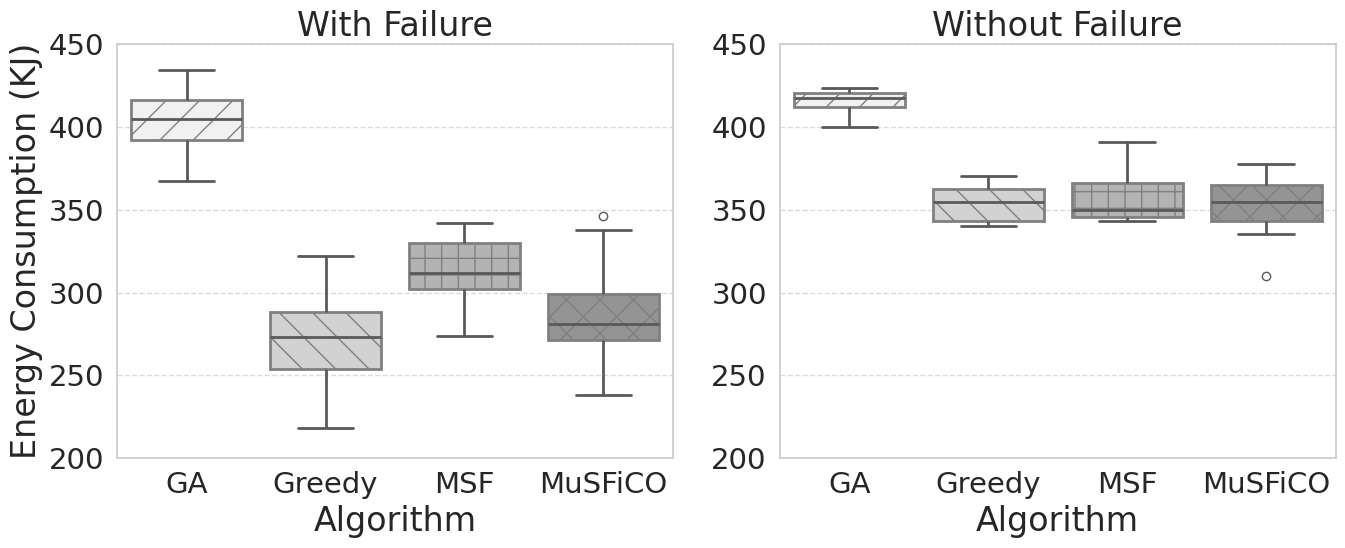

In [1238]:
mplot_dual_boxplot(dataframe1=dados_consumo_com_falha,
                        dataframe2=dados_consumo_sem_falha,
                        x_col="algorithm",y_col="energy_consumption_KJ",
                        title1="With Failure",title2="Without Failure",
                        y_range=(200, 450),y_title='Energy Consumption (KJ)',x_title='Algorithm')

In [447]:
aggregated_simulation_data = pd.DataFrame() 
algos = {}
def collect_data_from_alg_directory(results_res_directories):
    data_nla = []
    log_simu = {}  # Essa variável serve apenas para verificar as simulações

    for alg_dir in results_res_directories:
        simu_exec_name = alg_dir.split('/')[-1].split('_')
        alg_name = simu_exec_name[1].split("\\")[1]
        number_of_fails = simu_exec_name[-1]
        ava = simu_exec_name[-3]
        # reliability = simu_exec_name[-1]
        if alg_name == 'g':
            alg_name = 'Greedy'
        if alg_name == 'ga':
            alg_name =  'GA'
        if alg_name == 'msf':
            alg_name = 'MSF'
        if alg_name == 'goku':
            alg_name = 'OSCIM'
        if alg_name == 'vegeta':
            alg_name = 'Resilient-OSCIM'
        if alg_name == 'musfico':
            alg_name = 'MuSFiCO'
        if alg_name == 'old':
            alg_name = 'All Backup'
        files = os.listdir(alg_dir)
        #print(f"Simulação: {alg_name}, {reliability}") 
        #print("Quantidade de csv: ", len(files))
        
        if alg_name not in log_simu:
            log_simu[alg_name] = {'files': len(files), 'simulacoes_sucesso': 0, 'Nulos': 0}
        else:
            log_simu[alg_name]['files'] += len(files)

        for file in files:
            data_path = os.path.join(alg_dir, file)
            try:
                simulation_df = pd.read_csv(data_path)
            except Exception as e:
                print(f"Erro ao ler o arquivo {file}: {e}")
                continue

            if not simulation_df.empty: 
                # Calculations
                mean_data_frame = pd.DataFrame()
                recover_success_rate = simulation_df["recover_success"].mean()
                backup_success_rate = simulation_df["backup_success"].mean()
                latency_diff_mean = simulation_df["latency_diff"].dropna().mean()
                time_to_recover_mean = simulation_df["time_to_recover"].dropna().mean()

                # Cálculo do percentual de melhoria da latência
                improvement_percentage = ((5 - latency_diff_mean) / 10) * 100

                mean_data_frame["recover_success"] = [recover_success_rate]
                mean_data_frame["backup_success"] = [backup_success_rate]
                mean_data_frame["latency_diff"] = [latency_diff_mean]
                mean_data_frame["latency_improvement"] = [improvement_percentage]
                mean_data_frame["time_to_recover"] = [time_to_recover_mean]

                # Seleciona as métricas relevantes
                mean_data_frame['algorithm'] = alg_name
                mean_data_frame['simulation'] = log_simu[alg_name]['simulacoes_sucesso']
                print(mean_data_frame)
                # print(mean_data_frame)
                data_nla.append(mean_data_frame)

                # Incrementa a contagem de simulações de sucesso e soma os valores nulos
                log_simu[alg_name]['simulacoes_sucesso'] += 1
                log_simu[alg_name]['Nulos'] += sum(mean_data_frame.isnull().sum())
    if data_nla:
        data_nla_f = pd.concat(data_nla)
    else:
        data_nla_f = pd.DataFrame()

    print("\nResumo das Simulações:")
    for alg, info in log_simu.items():
        print(f"Algoritmo: {alg}")
        print(f"  Quantidade de arquivos: {info['files']}")
        print(f"  Simulações de sucesso: {info['simulacoes_sucesso']}")
        print(f"  Dados nulos: {info['Nulos']}")
        print()

    return data_nla_f

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Suposta estrutura do dataframe
# df = aggregated_simulation_data

# Apenas a métrica "recover_success"
metric = "recover_success"

# Configuração do estilo e tamanho da figura
sns.set(style="whitegrid", font_scale=1.2)

# Criação do gráfico de caixa para a métrica selecionada
plt.figure(figsize=(10, 6))
sns.boxplot(
    x="algorithm",
    y=metric,
    data=df,
    showmeans=True,
    meanprops={
        "marker": "o",
        "markerfacecolor": "red",
        "markeredgecolor": "black",
        "markersize": 8,
    },
    linewidth=1.5,
    fliersize=3,
)

# Personalização do gráfico
plt.title(f"Boxplot for {metric}", fontsize=18)
plt.xlabel("Algorithm", fontsize=14)
plt.ylabel(metric.replace("_", "


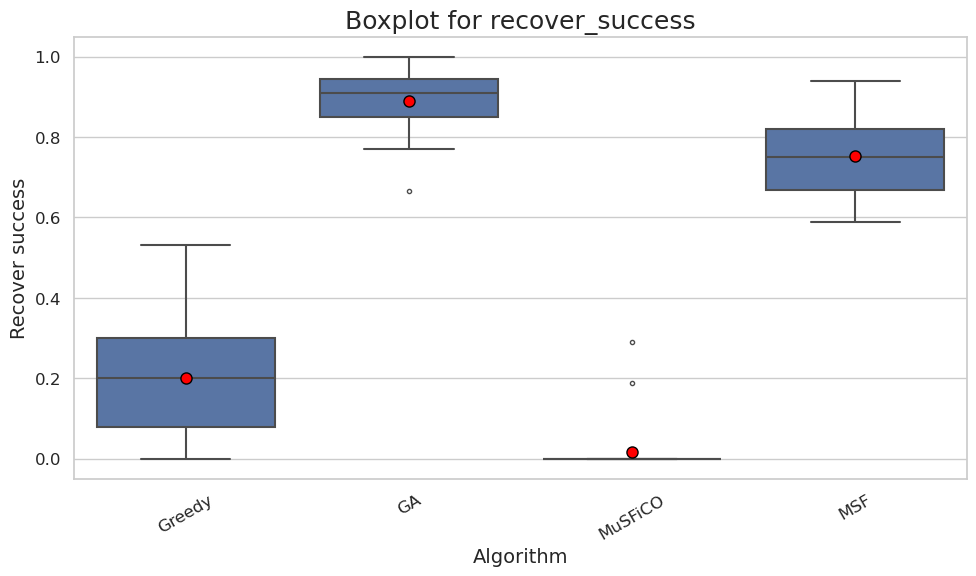

In [448]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Suposta estrutura do dataframe
# df = aggregated_simulation_data

# Apenas a métrica "recover_success"
metric = "recover_success"

# Configuração do estilo e tamanho da figura
sns.set(style="whitegrid", font_scale=1.2)

# Criação do gráfico de caixa para a métrica selecionada
plt.figure(figsize=(10, 6))
sns.boxplot(
    x="algorithm",
    y=metric,
    data=df,
    showmeans=True,
    meanprops={
        "marker": "o",
        "markerfacecolor": "red",
        "markeredgecolor": "black",
        "markersize": 8,
    },
    linewidth=1.5,
    fliersize=3,
)

# Personalização do gráfico
plt.title(f"Boxplot for {metric}", fontsize=18)
plt.xlabel("Algorithm", fontsize=14)
plt.ylabel(metric.replace("_", " ").capitalize(), fontsize=14)
plt.xticks(rotation=30, fontsize=12)
plt.yticks(fontsize=12)

# Ajusta o layout para melhor visualização
plt.tight_layout()

# Exibir o gráfico
plt.show()